# SWNT Raman analysis

Single-wall carbon nanotube spectra, using the `ramanfit_swnt` package:

**load → Si calibration → RBM (→ diameter, candidate (n,m)) → joint D-G fit → 2D → quality metrics**

Unlike the amorphous/MW-carbon D/G fit in `ramanfit.ipynb`, this:

- models the low-frequency **RBM** band (diameter fingerprint),
- fits the whole **D-G region jointly over 1000–1700 cm⁻¹** with four
  Lorentzians — **D**, a broad **D″** disorder band (~1500–1535), and the
  **G⁻/G⁺ doublet** — so the D-to-G valley is modelled instead of forced onto a
  straight baseline (R² ≈ 0.998 vs ≈ 0.98 for isolated windows),
- calibrates the shift axis against the **Si 520.7 cm⁻¹** substrate line.

In [1]:
import matplotlib.pyplot as plt
from ramanfit_swnt import load_spectrum, analyze_swnt, SwntConfig
from ramanfit_swnt.report import plot_analysis, summary_text

INFILE = "data/LA2026062501.tsv"   # 532 nm SWNT spectrum on Si
x, y = load_spectrum(INFILE)
print(f"{len(x)} points, {x[0]:.0f}–{x[-1]:.0f} cm⁻¹")

25732 points, 150–3600 cm⁻¹


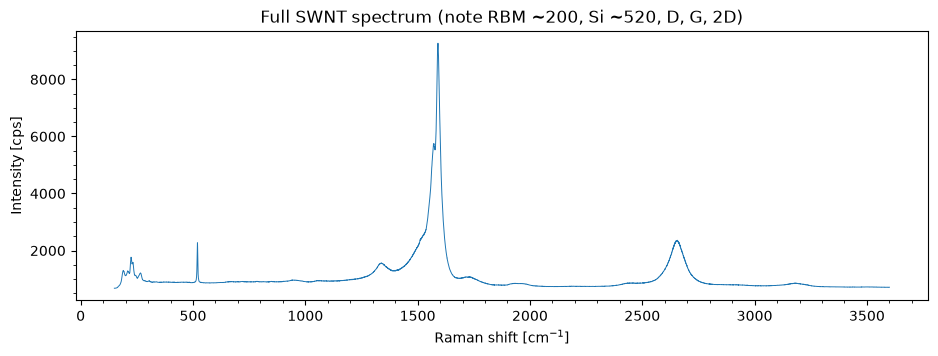

In [2]:
# Raw spectrum overview
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(x, y, lw=0.7)
ax.set(xlabel="Raman shift [cm$^{-1}$]", ylabel="Intensity [cps]",
       title="Full SWNT spectrum (note RBM ~200, Si ~520, D, G, 2D)")
ax.minorticks_on()
plt.show()

## Configure and run the pipeline

Adjust `laser_nm` (532/633/785), `gminus_lineshape` (`lorentzian` for
semiconducting, `bwf` for metallic tubes) or any region in `SwntConfig`.

In [3]:
cfg = SwntConfig(laser_nm=532, gminus_lineshape="lorentzian")
res = analyze_swnt(x, y, cfg)
print(summary_text(res))

Si calibration: observed 519.76 cm-1, offset -0.94 cm-1 (nominal 520.7)

RBM peaks (diameter, candidate (n,m)):
    191.2 cm-1  d=1.30 nm   -
    210.2 cm-1  d=1.18 nm   (15,0)M, (14,2)M, (10,7)M
    225.2 cm-1  d=1.10 nm   (11,5)M, (8,8)M, (12,3)M
    233.6 cm-1  d=1.06 nm   (13,1)M, (12,3)M, (8,8)M
    246.6 cm-1  d=1.01 nm   (9,6)M, (13,1)M
    266.2 cm-1  d=0.93 nm   -
    305.9 cm-1  d=0.81 nm   (9,2)S, (10,0)S, (8,3)S

D-G joint fit (R²=0.9993):
  D   1338.9 cm-1 (FWHM 88)
  D'' 1522.1 cm-1 (FWHM 132, broad disorder band)
  G+  1591.4, G- 1569.5 (split 21.9 cm-1) -> semiconducting
  D'  1599.5 cm-1 (FWHM 27)
I(D)/I(G+) = 0.110

2D region (4 components, R²=0.9998):
  G*   2433.4 cm-1 (FWHM 212, height 226)
  2D   2606.6 cm-1 (FWHM 82, height 143)
  2D   2655.2 cm-1 (FWHM 74, height 1543)
  2D   2689.3 cm-1 (FWHM 50, height 128)
  dominant 2D 2655.2 cm-1, I(2D)/I(G+) = 0.305


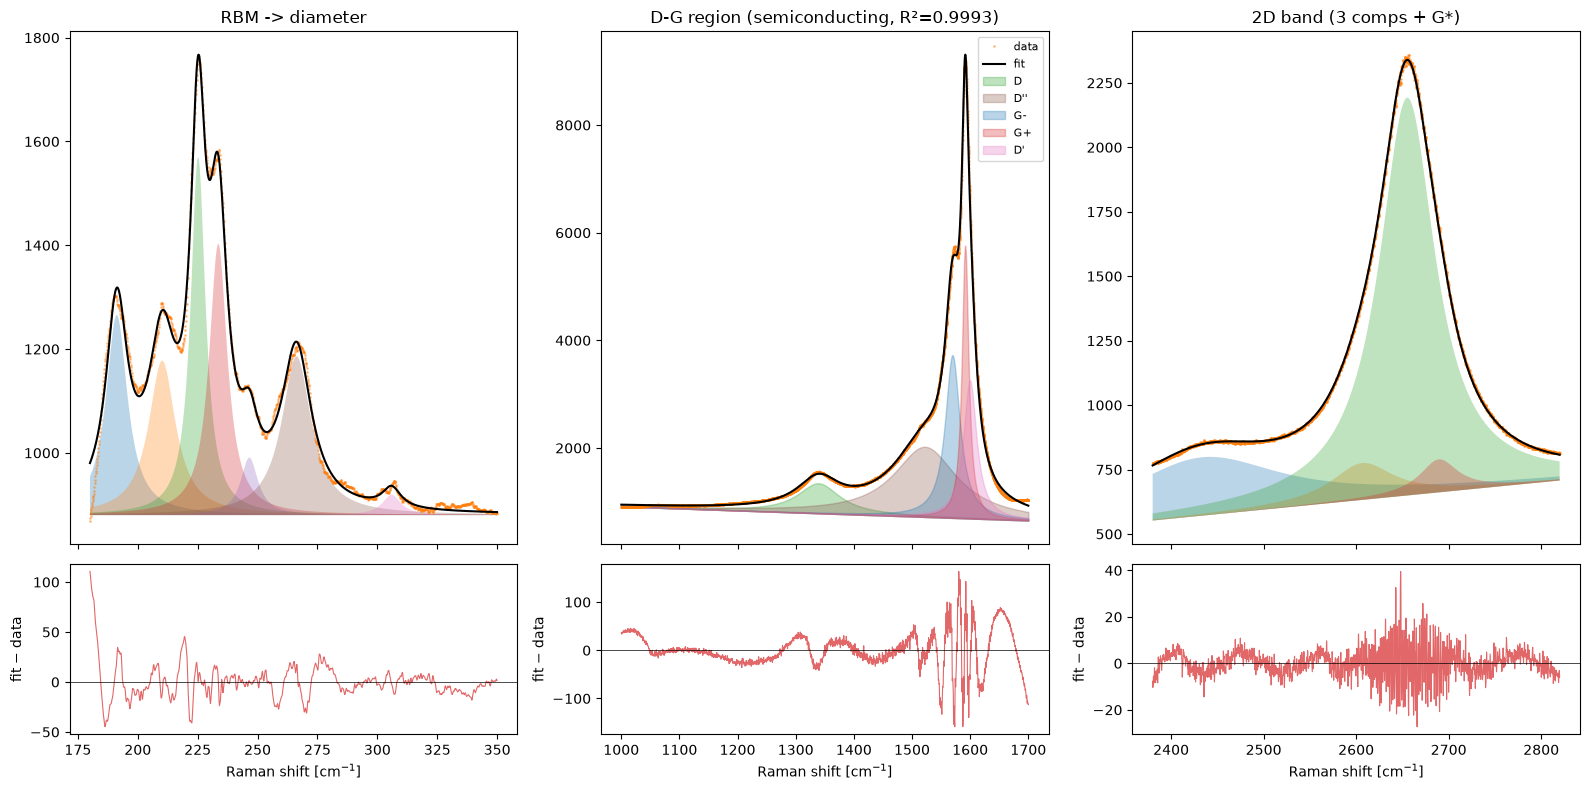

In [4]:
# Four-panel decomposition: RBM / D-G joint fit / D-G residual / 2D
fig = plot_analysis(res)
plt.show()

## RBM → diameter → candidate (n,m)

(n,m) candidates come from a first-order tight-binding Kataura model and are
**approximate** — see `ramanfit_swnt/kataura.py`.

In [5]:
for pk in res["rbm"]["peaks"]:
    nm = ", ".join(f"({c['n']},{c['m']}){c['type']}"
                   for c in pk.get("nm_candidates", [])[:3]) or "—"
    print(f"RBM {pk['center']:7.1f} cm⁻¹   d = {pk['diameter_nm']:.3f} nm   {nm}")

RBM   191.2 cm⁻¹   d = 1.297 nm   —
RBM   210.2 cm⁻¹   d = 1.180 nm   (15,0)M, (14,2)M, (10,7)M
RBM   225.2 cm⁻¹   d = 1.101 nm   (11,5)M, (8,8)M, (12,3)M
RBM   233.6 cm⁻¹   d = 1.062 nm   (13,1)M, (12,3)M, (8,8)M
RBM   246.6 cm⁻¹   d = 1.006 nm   (9,6)M, (13,1)M
RBM   266.2 cm⁻¹   d = 0.931 nm   —
RBM   305.9 cm⁻¹   d = 0.811 nm   (9,2)S, (10,0)S, (8,3)S


## D-G band peaks (joint fit)

Centers, widths and uncertainties for the four components fit jointly over
1000–1700 cm⁻¹. The broad **D″** band fills the D-to-G valley; finite
`center ±` values confirm the fit is well-determined (not railed).

In [6]:
dg = res["dg"]
print(f"D-G joint fit  R² = {dg['r_squared']:.4f}  ({'metallic' if dg['metallic'] else 'semiconducting'})\n")
print(f"{'peak':4s} {'center':>9s} {'± (cm⁻¹)':>9s} {'FWHM':>7s} {'height':>9s}")
for rec in (dg['D'], dg['Dpp'], dg['G_minus'], dg['G_plus'], dg['Dprime']):
    ce = rec.get('center_stderr')
    ce_s = f"{ce:.2f}" if ce is not None else "  n/a"
    print(f"{rec['label']:4s} {rec['center']:9.1f} {ce_s:>9s} "
          f"{rec.get('fwhm', float('nan')):7.1f} {rec['height']:9.0f}")

D-G joint fit  R² = 0.9993  (semiconducting)

peak    center  ± (cm⁻¹)    FWHM    height
D       1338.9      0.21    88.4       559
D''     1522.1      0.43   132.4      1304
G-      1569.5      0.04    30.9      3025
G+      1591.4      0.03    13.9      5066
D'      1599.5      0.24    27.4      2570


## 2D region (multi-component)

The 2D region (2380–2820 cm⁻¹) is fit jointly with two physically distinct
families: the broad **G\*** (iTOLA combination band, ~2450 cm⁻¹) and the **2D**
overtone (~2655) modelled as a main peak plus shoulders — contributions from the
diameter distribution / different (n,m) species. Negligible components are pruned;
the I(2D)/I(G) metric uses the dominant 2D peak (not G\*).

In [7]:
t2d = res["twod_band"]
print(f"2D region: {len(t2d['peaks'])} components  (R² = {t2d['r_squared']:.4f})\n")
print(f"{'band':5s} {'center':>9s} {'FWHM':>7s} {'height':>9s}")
for pk in sorted(t2d["peaks"], key=lambda r: r["center"]):
    print(f"{pk['label']:5s} {pk['center']:9.1f} {pk['fwhm']:7.1f} {pk['height']:9.0f}")
print(f"\ndominant 2D {t2d['peak']['center']:.1f} cm⁻¹,  I(2D)/I(G⁺) = {res['quality']['I2D_IG']:.3f}")

2D region: 4 components  (R² = 0.9998)

band     center    FWHM    height
G*       2433.4   212.0       226
2D       2606.6    82.3       143
2D       2655.2    74.1      1543
2D       2689.3    50.2       128

dominant 2D 2655.2 cm⁻¹,  I(2D)/I(G⁺) = 0.305


## Si calibration & quality metrics

In [8]:
cal = res["calibration"]
g = res["gband"]
q = res["quality"]
print(f"Si calibration applied: {cal['applied']}  (offset {cal['offset']:+.2f} cm⁻¹)")
print(f"G⁺ = {g['G_plus']['center']:.1f}, G⁻ = {g['G_minus']['center']:.1f} cm⁻¹")
print(f"character: {'metallic' if g['metallic'] else 'semiconducting'}")
print(f"I(D)/I(G⁺) = {q['ID_IG']:.3f}   (low → high quality / few defects)")
print(f"2D = {q['twod_center']:.1f} cm⁻¹,  I(2D)/I(G⁺) = {q['I2D_IG']:.3f}")

Si calibration applied: True  (offset -0.94 cm⁻¹)
G⁺ = 1591.4, G⁻ = 1569.5 cm⁻¹
character: semiconducting
I(D)/I(G⁺) = 0.110   (low → high quality / few defects)
2D = 2655.2 cm⁻¹,  I(2D)/I(G⁺) = 0.305


## Save a summary

In [9]:
with open("swnt_summary.txt", "w") as f:
    f.write(summary_text(res))
print("wrote swnt_summary.txt")

wrote swnt_summary.txt
